In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_mistralai import ChatMistralAI
from langgraph.checkpoint.memory import MemorySaver
from rich import print

In [7]:
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [8]:
llm = ChatMistralAI(model="mistral-small-2506")

def chat_node(state: ChatState) -> ChatState:
  # user query from state
  messages = state['messages']

  # send it to llm
  response = llm.invoke(messages)

  # store response in the state
  return {'messages': [response]}

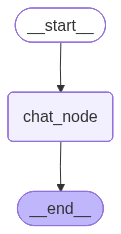

In [9]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# nodes
graph.add_node("chat_node", chat_node)

# edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chat_bot = graph.compile(checkpointer=checkpointer)

chat_bot

In [10]:
thread_id = '1'

while True:
  user_message = input("user: ")
  print("user:",user_message)

  if user_message.strip().lower() in ['exit', 'quit', 'bye']:
    print("ai: byebye")
    break

  config = {'configurable': {'thread_id': thread_id}}
  response = chat_bot.invoke({'messages': [HumanMessage(user_message)]}, config=config)

  print("ai:", response['messages'][-1].content)

user: hi

ai: Hello! 😊 How can I help you today?

user: im anish

ai: Nice to meet you, Anish! 👋 How can I assist you today? Whether you have a question, need help with something, 
or just want to chat, I'm here for you. Let me know! 😊

user: what is my name?

...

ai: Let's add them step by step:

1. **100 + 200 = 300**
2. **300 + 200 = 500**

**Final Answer:** **500** ✅

(Or, if you prefer a shortcut: **100 + 200 + 200 = 500** directly!) 😊

user: now multiply that by 50

ai: Let's break it down:

1. **500 × 50** can be calculated as:
   - **500 × 5 = 2,500** (since 50 is 5 × 10)
   - Then, **2,500 × 10 = 25,000**

**Final Answer:** **25,000** ✅

(Or, if you prefer: **500 × 50 = 25,000** directly!) 😊

user: bye

ai: byebye

In [11]:
print(chat_bot.get_state(config=config))

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='hi',
                additional_kwargs={},
                response_metadata={},
                id='301521b2-cb3c-4a69-a857-8e99328874b3'
            ),
            AIMessage(
                content='Hello! 😊 How can I help you today?',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 4,
                        'total_tokens': 17,
                        'completion_tokens': 13,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019d8ba2-1bb1-7fd3-b182-56f0dabdf587-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}
            ),
            HumanMessage(
                content='im anish',
                additional_kwargs={},
                response_metadata={},
                id='6a89ac04-3d78-4537-88c0-796723a50edd'
            ),
            AIMessage(
                content="Nice to meet you, Anish! 👋 How can I assist you today? Whether you have a question, need 
help with something, or just want to chat, I'm here for you. Let me know! 😊",
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 22,
                        'total_tokens': 71,
                        'completion_tokens': 49,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019d8ba2-2b56-79c3-b3f4-71672f4cbe62-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 22, 'output_tokens': 49, 'total_tokens': 71}
            ),
            HumanMessage(
                content='what is my name?',
                additional_kwargs={},
                response_metadata={},
                id='a74d59ae-fadf-41da-be50-11f26b8c1d69'
            ),
            AIMessage(
                content="You told me your name is **Anish**! 😊\n\n(But if you'd like to correct or change it, just
let me know—I’m happy to update it!) 🚀",
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 78,
                        'total_tokens': 120,
                        'completion_tokens': 42,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-2506',
                    'model': 'mistral-small-2506',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019d8ba2-3b70-7112-9d48-e27dee4b2efe-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 78, 'output_tokens': 42, 'total_tokens': 120}
            ),
            HumanMessage(
                content='add 100 + 200 + 200',
                additional_kwargs={},
                response_metadata={},
                id='bbcf35f4-ff0c-4fb4-9da9-ec0718d05adb'
            ),
            AIMessage(
                content="Let's add them step by step:\n\n1. **100 + 200 = 300**\n2. **300 + 200 = 500**\n\n**Final 
Answer:** **500** ✅\n\n(Or, if you prefer a 